### Soccer Passing Networks

In [1]:
import sys
import os
from statsbombpy import sb
import warnings
import pandas as pd

warnings.filterwarnings("ignore", category = UserWarning, module = "statsbombpy")
sys.path.append(os.path.abspath(".."))

from matplotlib import pyplot as plt
plt.rcParams['figure.dpi'] = 1000

In [2]:
from Utils.dataCollection import APICall, collectDataOneGame
from Utils.dataProcessing import buildGlobalPlayerDict, multiGameCollection
from Utils.visualization import createPassingNetwork, playerHeatmap

##### Calling API from StatsBomb

In [3]:
sb.competitions()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882
...,...,...,...,...,...,...,...,...,...,...,...,...
70,35,75,Europe,UEFA Europa League,male,False,False,1988/1989,2024-02-12T14:45:05.702250,2021-06-13T16:17:31.694,None,2024-02-12T14:45:05.702250
71,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2025-07-28T14:19:20.467348,2025-07-29T16:03:07.355174,2025-07-29T16:03:07.355174,2025-07-28T14:19:20.467348
72,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2024-02-13T13:27:17.178263,2024-02-13T13:30:52.820588,2024-02-13T13:30:52.820588,2024-02-13T13:27:17.178263
73,72,107,International,Women's World Cup,female,False,True,2023,2025-07-14T10:07:06.620906,2025-07-14T10:10:27.224586,2025-07-14T10:10:27.224586,2025-07-14T10:07:06.620906


Selecting Desired Competition and Season

In [4]:
competitionId = 11
seasonId = 1
teamName = "Barcelona"

In [5]:
matches = APICall(competitionId, seasonId, teamName)

Processing Games: 100%|██████████| 36/36 [00:19<00:00,  1.83it/s]


##### Multi Game Data Collection

In [6]:
gameDfs, playerInformation = multiGameCollection(matches, teamName)

In [7]:
gameDfs[0].head(10)

,Sender,Receiver,Timestamp,Type,xG,Location
0,4,9,20,Pass,0.0,"[34.8, 23.4]"
1,9,24,21,Pass,0.0,"[36.6, 20.1]"
2,24,9,28,Pass,0.0,"[9.6, 38.9]"
3,9,3,32,Pass,0.0,"[10.7, 9.6]"
4,3,5,36,Pass,0.0,"[3.8, 2.8]"
5,9,5,37,Pass,0.0,"[2.5, 6.9]"
6,9,6,63,Pass,0.0,"[14.9, 4.1]"
7,3,2,75,Pass,0.0,"[50.5, 7.7]"
8,2,4,79,Pass,0.0,"[42.0, 23.6]"
9,4,16,83,Pass,0.0,"[44.2, 65.5]"


##### Creating Passing Visualization

Threshold is the minimum amount of passes a player needs to make to be displayed in the graph, which prevents low impact players from being graphed. Margin is just node spacing. 

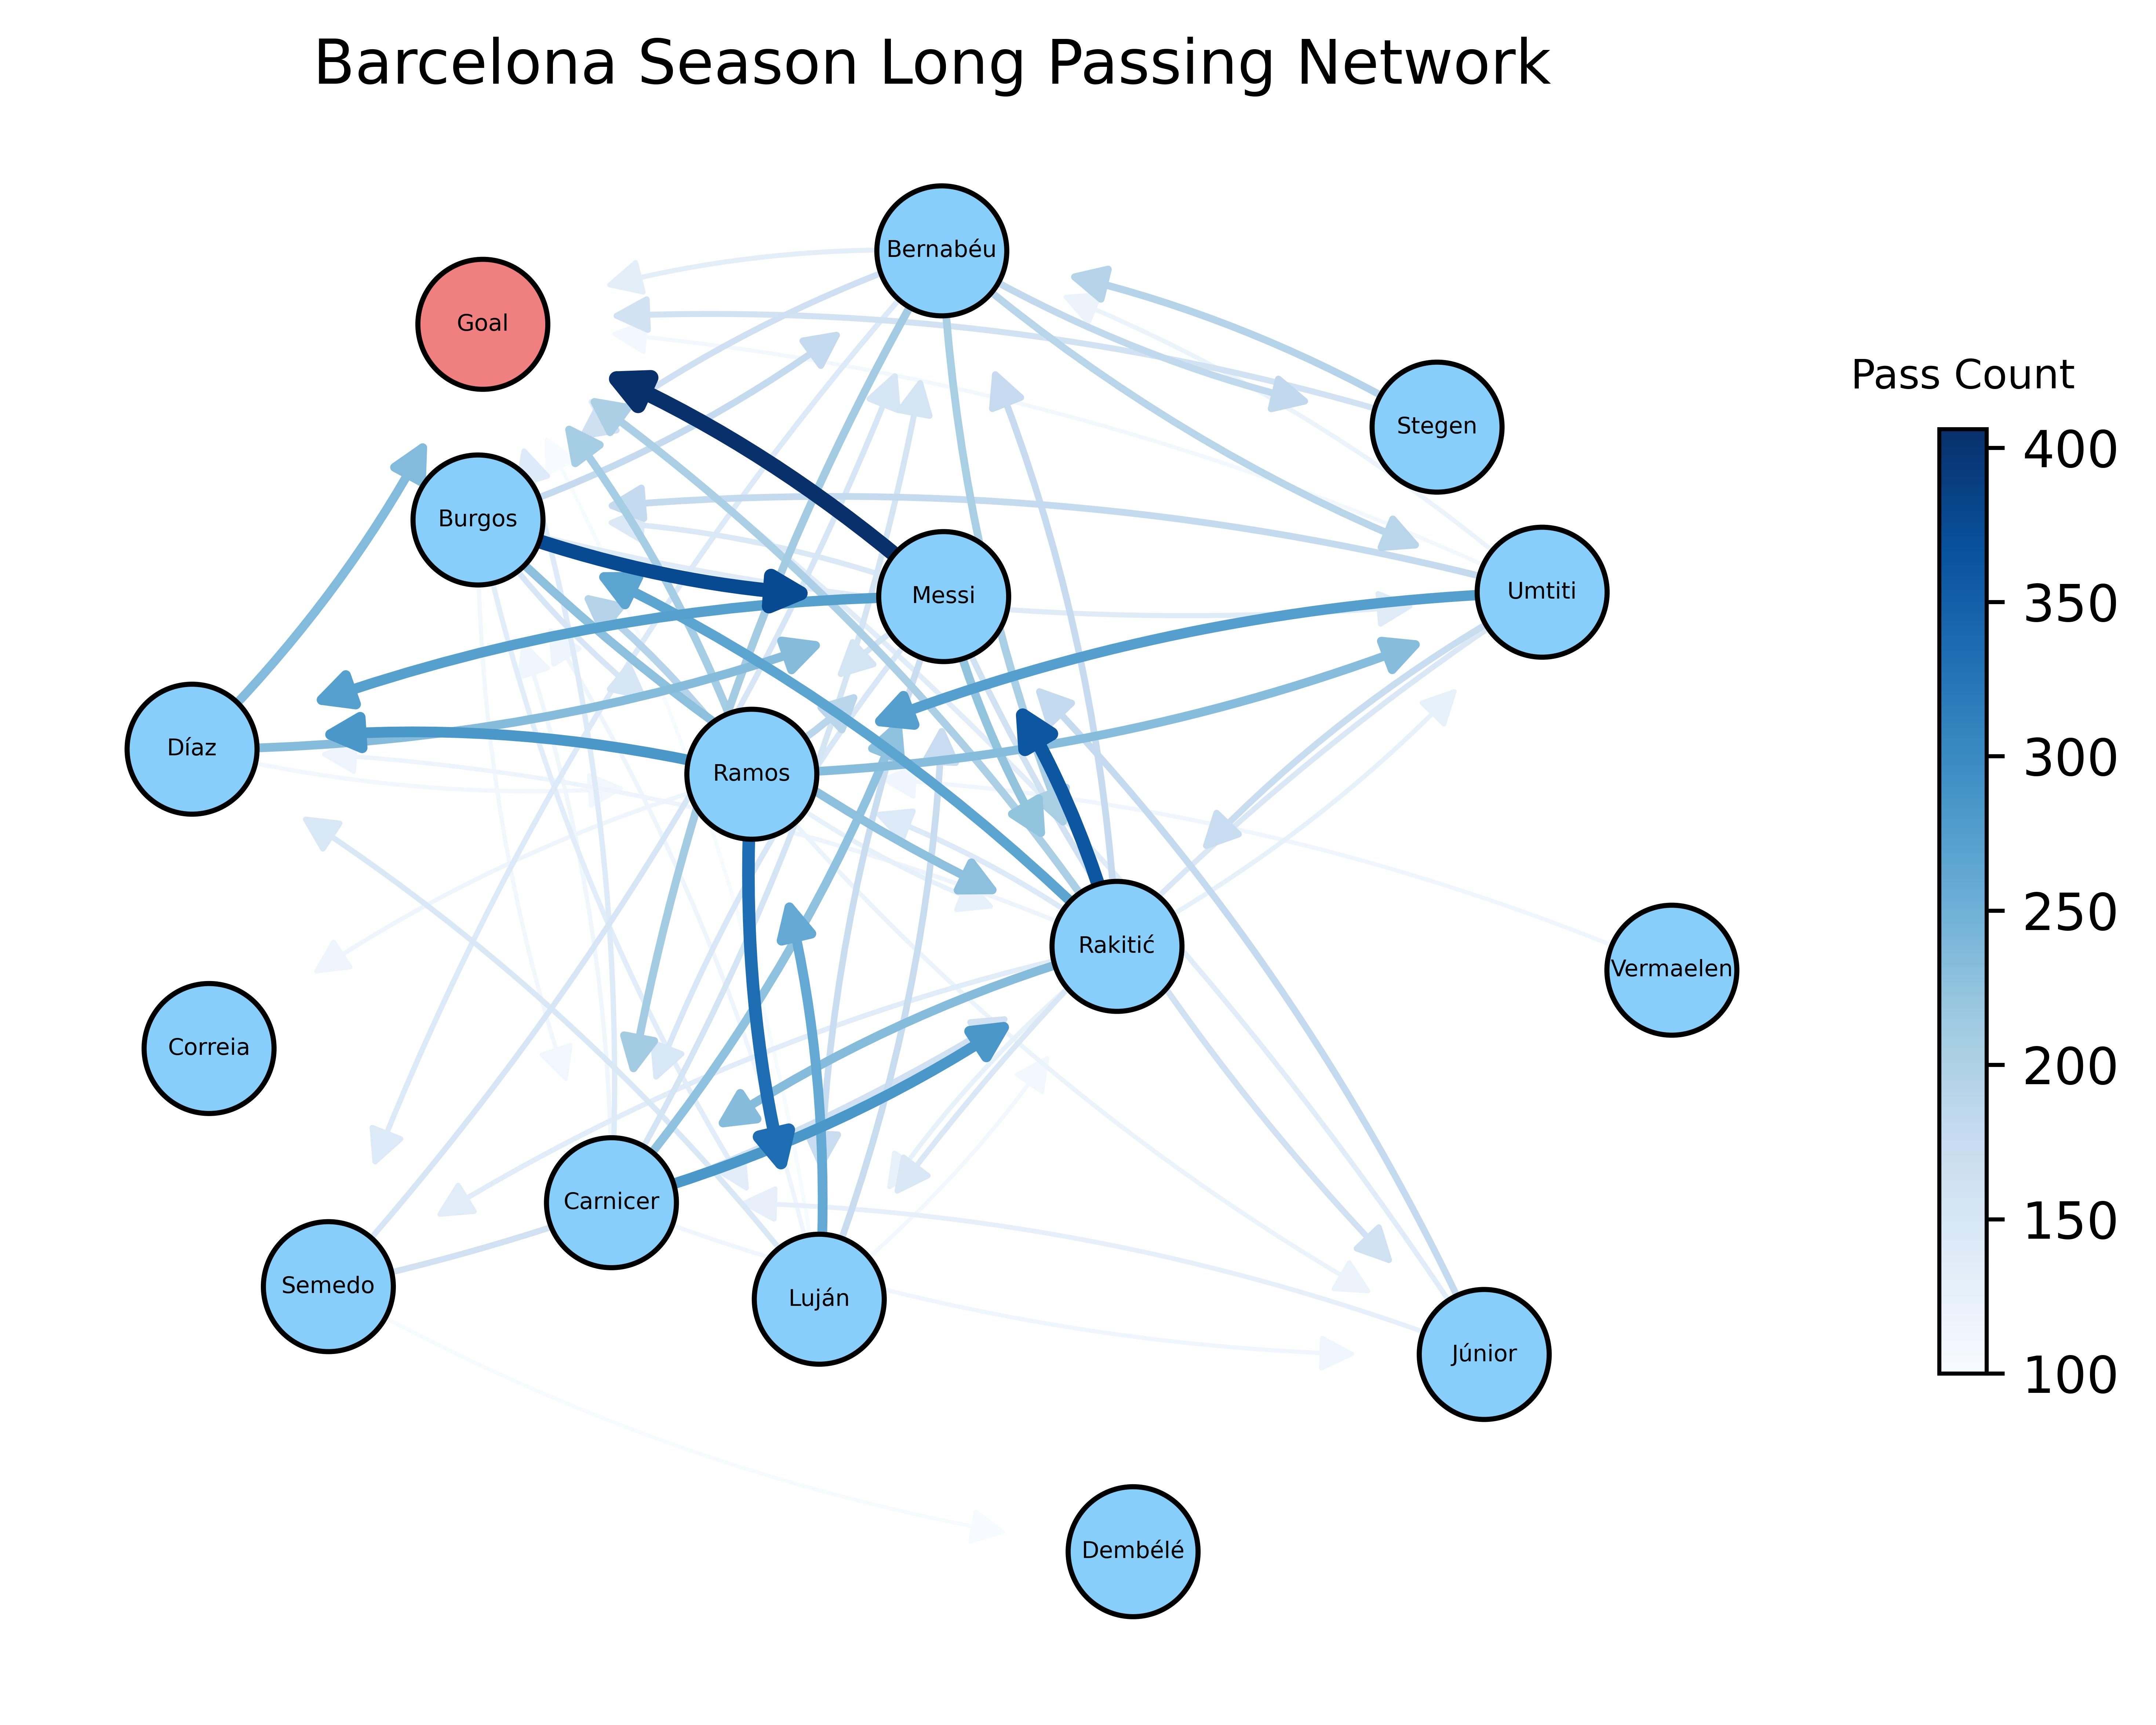

In [8]:
threshold = 100
margin = 25

createPassingNetwork(teamName, gameDfs, 100, playerInformation, 25)

##### Passing Heatmap

Player IDs can be found in the player information dictionary so that passing heatmaps can be generated for all players. 

In [9]:
playerHeatmap(gameDfs, 5503, "Lionel Messi", "Barcelona", playerInformation)